In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# 1. Load Clean Data

In [2]:
df_raw = pd.read_csv('clean_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# 2. Data Preprocessing

In this phase, I used manual mapping, Label Encoding, and One-Hot Encoding to correctly represent ordinal, binary, and nominal features for the machine learning models.

In [4]:
df = df.drop(columns='customerID')

In [5]:
label = LabelEncoder()

In [6]:
label_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
ohe_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod']

In [7]:
mapping = {'Month-to-month': 0,
           'One year': 1,
           'Two year': 2
          }
df['Contract'] = df['Contract'].map(mapping)
for col in label_cols:
    df[col] = label.fit_transform(df[col])
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,1,0,1,0,0,0,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0


# 3. Split Data

In this phase, I will split the data into training and test sets. Since our target variable (Churn) is highly imbalanced (Class 0: 5174, Class 1: 1869), I am using stratify=y for the initial split and StratifiedKFold for cross-validation. This ensures that the proportion of churned to retained customers remains consistent across all folds.

Additionally, I decided to drop the TotalCharges column due to its strong multicollinearity with tenure (Pearson's r = 0.83).

In [9]:
y = df['Churn']
X = df.drop(columns=['Churn','TotalCharges'])
kfold = StratifiedKFold(n_splits=5, random_state=7, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=7
)

# 4. Results Functions

I developed Python functions to show confusion matrix, models metrics and feature importance.

In [10]:
def show_matrix(cm):
        plt.figure(figsize=(5,5))
        sns.heatmap(cm, cmap='inferno', annot=True, fmt='.2f', square=True, cbar=False, xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
        plt.show()
def show_results(cm):
        TN = cm[0,0]
        FP = cm[0,1]
        FN = cm[1,0]
        TP = cm[1,1]
        Precision = TP / (TP + FP)
        Recall = TP / (TP + FN)
        Specificity = TN / (TN + FP)
        Accuracy = (TP + TN) / (TP + TN + FP + FN)
        F1  = (2 * Precision * Recall) / (Precision + Recall)                
        results = print(f"""
        Precision: {Precision}
        Recall: {Recall}
        Specificity: {Specificity}
        Accuracy: {Accuracy}
        F1 Score: {F1}
        """)

def coefficients(model, feature_names, top_n=15):
    coefs = model.named_steps['log_reg'].coef_[0]
    fi = pd.Series(coefs, index=feature_names)
    fi = fi.abs().sort_values(ascending=True).tail(top_n)
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh')
    plt.title('Feature Importance - Logistic Regression Tuned')
    plt.xlabel('Absolute coefficient value')
    plt.tight_layout()
    plt.show()
                   
def feature_importance(model, feature_names, title, top_n=15):
    estimator = model
    importances = estimator.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    fi.plot(kind='barh', color='teal')
    plt.title(f'Feature Importances - {title}', fontsize=14)
    plt.xlabel('Absolute coefficient value', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    

# 4. Logistic Regression (Baseline Model)

# 4.1 First Model (Default settings)

In [11]:
model_log = make_pipeline(StandardScaler(), LogisticRegression())
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
cm_log = confusion_matrix(y_test, y_pred_log)

### 4.1.1 Model Results

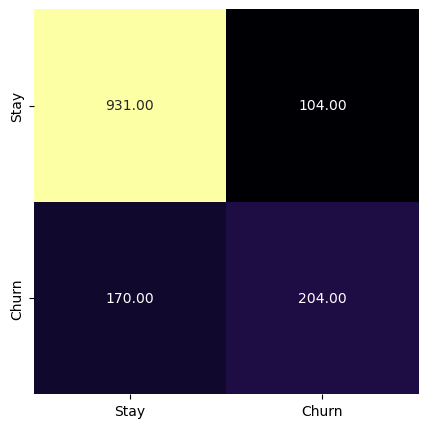


        Precision: 0.6623376623376623
        Recall: 0.5454545454545454
        Specificity: 0.8995169082125604
        Accuracy: 0.8055358410220014
        F1 Score: 0.5982404692082111
        


In [12]:
show_matrix(cm_log)
show_results(cm_log)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 204 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 170 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 104 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 54.54%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 66.23% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 59.82%.

## 4.2 Handling Class Imbalance (F1-Score Optimization)

Since the dataset is highly imbalanced, accuracy as a default scoring metric would be misleading. F1 score better captures the trade-off between Precision and Recall for the minority Churn class.

In [13]:
pipe_log_f = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=7))
])
param_grid_log_f = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l1','l2'],
    'log_reg__solver': ['liblinear'],
    'log_reg__class_weight': ['balanced', None]
}
grid_search_log_f = GridSearchCV(estimator=pipe_log_f,
                           param_grid = param_grid_log_f,
                           cv=kfold,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)
grid_search_log_f.fit(X_train, y_train)
print('The best parameters:', grid_search_log_f.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters: {'log_reg__C': 1, 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l1', 'log_reg__solver': 'liblinear'}


In [14]:
best_model_log_f = grid_search_log_f.best_estimator_
y_pred_log_f = best_model_log_f.predict(X_test)
y_prob_log_f = best_model_log_f.predict_proba(X_test)[:,1]
roc_auc_log_f = roc_auc_score(y_test, y_prob_log_f)
cm_log_f = confusion_matrix(y_test, y_pred_log_f)

### 4.2.1 Model Results

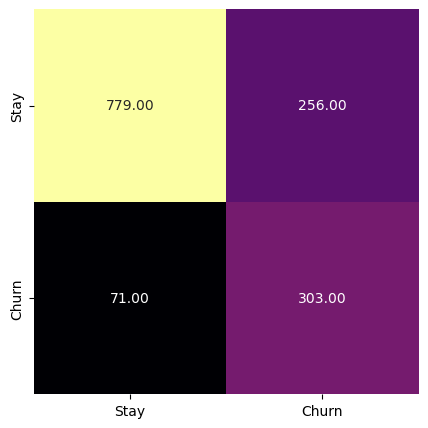


        Precision: 0.5420393559928444
        Recall: 0.8101604278074866
        Specificity: 0.7526570048309179
        Accuracy: 0.7679205110007097
        F1 Score: 0.6495176848874599
        
ROC-AUC: 0.8546410395515254


In [15]:
show_matrix(cm_log_f)
show_results(cm_log_f)
print(f"ROC-AUC: {roc_auc_log_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 303 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 71 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 256 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 81.01%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 54.20% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 64.95%.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 85.46%, indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (54.54% vs 81.02%), dropping the number of missed churners from 170 to just 71. The drop in Precision is an expected consequence of `class_weight='balanced'`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 4.2.2 Feature Importance

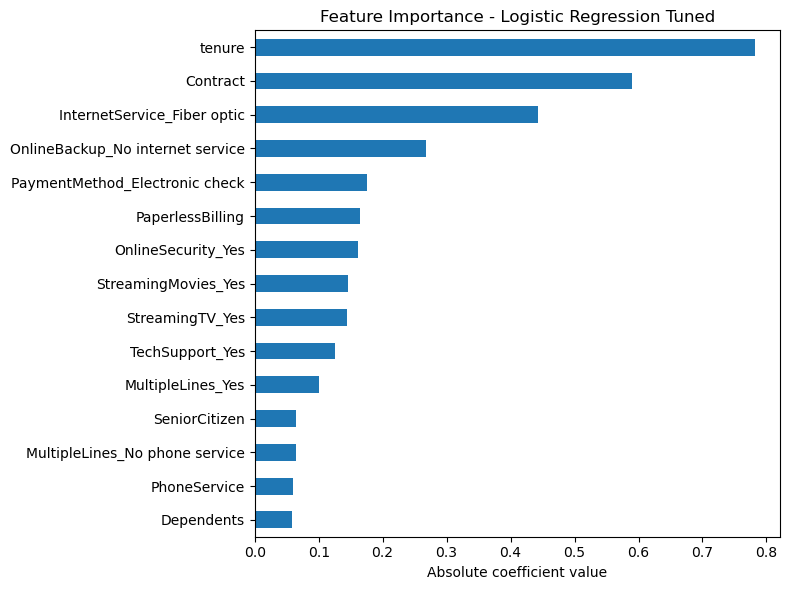

In [16]:
coefficients(best_model_log_f, X_train.columns)

**Insights:**

The three most influential features are tenure (~ 0.78),  Contract (~ 0.61) and InternetService_Fiber optic (~ 0.47).

# 5. Random Forest Classifier

## 5.1 First Model (Default settings)

In [17]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

### 5.1.1 Model Results

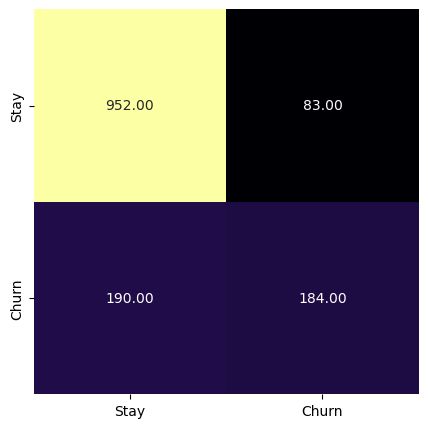


        Precision: 0.6891385767790262
        Recall: 0.4919786096256685
        Specificity: 0.9198067632850242
        Accuracy: 0.8062455642299503
        F1 Score: 0.5741029641185648
        


In [18]:
show_matrix(cm_rf)
show_results(cm_rf)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 188 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 186 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 86 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 50.27 %
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 68.61 % of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 58.02 %.

## 5.2 Handling Class Imbalance (F1-Score Optimization)

In [19]:
rf_f_model = RandomForestClassifier(random_state=7)

param_grid_rf_f = {
    'n_estimators': [50, 100, 200, 250, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 5, 7, 9, 11, 13, 15],
    'class_weight': ['balanced']
}
grid_search_rf_f = GridSearchCV(estimator=rf_f_model,
                           param_grid = param_grid_rf_f,
                           cv=kfold,
                            scoring='f1', 
                           n_jobs=-1,
                           verbose=1)
grid_search_rf_f.fit(X_train , y_train)
print('The best parameters:', grid_search_rf_f.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
The best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 13, 'n_estimators': 200}


In [20]:
best_model_rf_f = grid_search_rf_f.best_estimator_
y_pred_rf_f = best_model_rf_f.predict(X_test)
y_prob_rf_f = best_model_rf_f.predict_proba(X_test)[:,1]
roc_auc_rf_f = roc_auc_score(y_test, y_prob_rf_f)
cm_rf_f = confusion_matrix(y_test, y_pred_rf_f)

### 5.2.1 Model Results

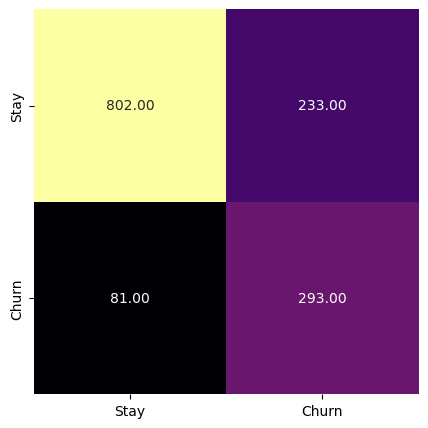


        Precision: 0.5570342205323194
        Recall: 0.7834224598930482
        Specificity: 0.77487922705314
        Accuracy: 0.7771469127040455
        F1 Score: 0.6511111111111111
        
ROC-AUC: 0.8625229274845643


In [21]:
show_matrix(cm_rf_f)
show_results(cm_rf_f)
print(f"ROC-AUC: {roc_auc_rf_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 293 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 81 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 233 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 78.34 %
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 55.70 % of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 65.11 %.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 86.25 % indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (50.27 % vs 78.34 %), dropping the number of missed churners from 186 to just 81. The drop in Precision is an expected consequence of `class_weight='balanced'`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 5.2.2 Feature Importance

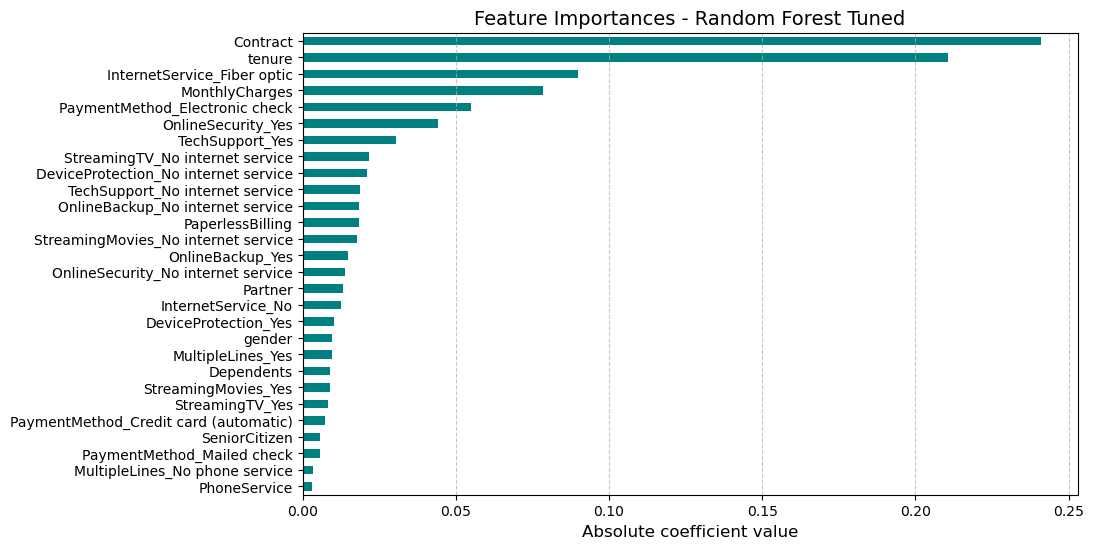

In [22]:
feature_importance(best_model_rf_f, X_train.columns, 'Random Forest Tuned')

**Insights:**

The three most influential features are Contract (~ 0.23), tenure (~ 0.21) and InternetService_Fiber optic (~ 0.08).

# 6. XGBClassifier

## 6.1 First Model (Default settings)

In [23]:
model_xgb =  XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

### 6.1.1 Model Results

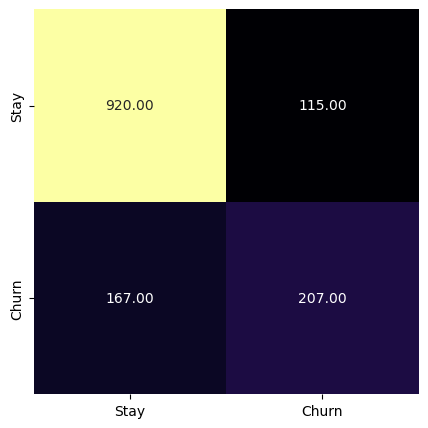


        Precision: 0.6428571428571429
        Recall: 0.553475935828877
        Specificity: 0.8888888888888888
        Accuracy: 0.7998580553584103
        F1 Score: 0.5948275862068965
        


In [24]:
show_matrix(cm_xgb)
show_results(cm_xgb)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 207 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 167 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 115 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 55.35 %
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 64.29 % of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 59.48 %.

## 6.2 Handling Class Imbalance (F1-Score Optimization)

In [25]:
model_xgb_f = XGBClassifier(random_state=7, 
                            eval_metric='logloss',
                            tree_method='hist',
                            device='cuda' 
                           )

param_grid_xgb_f = {
    'n_estimators': [100,200],
    'max_depth': [2,3,5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'scale_pos_weight': [2.7 ,2.8],
    'min_child_weight': [5, 15, 20],       
    'colsample_bytree': [0.8, 1.0]
}
grid_search_xgb_f = GridSearchCV(estimator=model_xgb_f,
                           param_grid = param_grid_xgb_f,
                           cv=kfold,
                           scoring='f1', 
                           n_jobs=1,
                           verbose=1)
grid_search_xgb_f.fit(X_train , y_train)
print('The best parameters:', grid_search_xgb_f.best_params_)
    

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


C:\Users\Oliwer\anaconda3\Lib\site-packages\xgboost\core.py:774: UserWarning: [13:35:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


The best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'scale_pos_weight': 2.7}


In [26]:
best_model_xgb_f = grid_search_xgb_f.best_estimator_
y_pred_xgb_f = best_model_xgb_f.predict(X_test)
y_prob_xgb_f = best_model_xgb_f.predict_proba(X_test)[:,1]
roc_auc_xgb_f = roc_auc_score(y_test, y_prob_xgb_f)
cm_xgb_f = confusion_matrix(y_test, y_pred_xgb_f)

### 6.2.1 Model Results

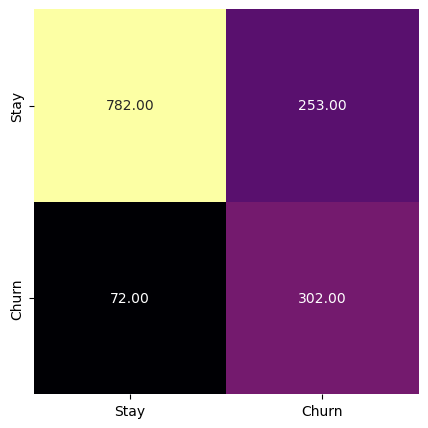


        Precision: 0.5441441441441441
        Recall: 0.8074866310160428
        Specificity: 0.7555555555555555
        Accuracy: 0.7693399574166075
        F1 Score: 0.6501614639397202
        
ROC-AUC: 0.8621392957710095


In [27]:
show_matrix(cm_xgb_f)
show_results(cm_xgb_f)
print(f"ROC-AUC: {roc_auc_xgb_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 302 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 72 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 253 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 80.75 %
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 54.41 % of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 65.02 %.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 86.21% indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (55.35% vs 80.75 %), dropping the number of missed churners from 167 to just 72.The drop in Precision is an expected consequence of `scale_pos_weight`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 6.2.2 Feature Importance

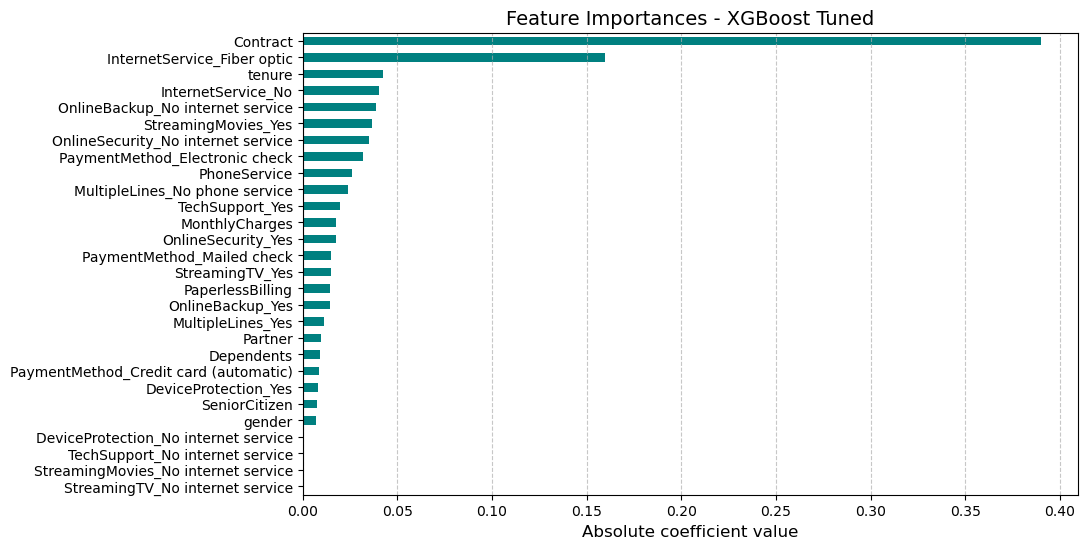

In [28]:
feature_importance(best_model_xgb_f, X_train.columns, 'XGBoost Tuned')

**Insights:**

The two most influential features are Contract (~ 0.37) and InternetService_Fiber optic (~ 0.16).

# 7. Model Comparison

## 7.1 Results Summary

The table below summarizes the performance of all models.

|Model|Precision|Recall|Specificity|Accuracy|F1|ROC-AUC|FN|
|:-----|:------|:------|:--------|:-------|:------|:-----|:-----|
|LR Default|66.23 %|54.54 %|89.95 %|80.55 %|59.82 %|-|170|
|LR Tuned|54.20 %|81.02 %|75.27 %|76.79 %|64.95 %|85.47 %|71|
|RF Default|68.91 %|49.19 %|91.98%|80.62%|57.41 %|-|190|
|RF Tuned|55.70 %|78.32 %|77.49 %|77.15 %|65.11 %|86.25 %|81|
|XGB Default|64.29 %|53.35 %|88.89 %|79.99 %|58.48 %|-|167|
|XGB Tuned|54.41 %|80.75%|75.76 %|76.93 %|65.02 %|86.21 %|72|

## 7.2 ROC Curve

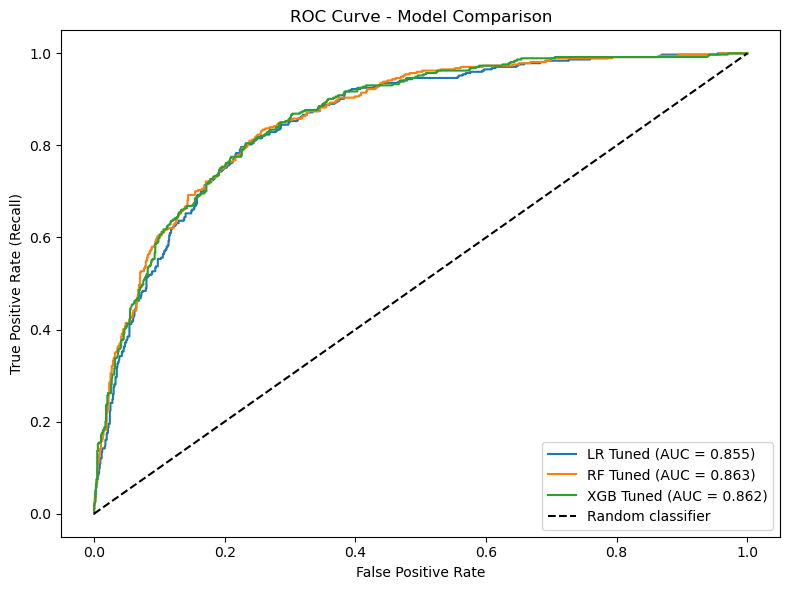

In [36]:
models = {
    'LR Tuned': (best_model_log_f, 'tuned'),
    'RF Tuned': (best_model_rf_f, 'tuned'),
    'XGB Tuned': (best_model_xgb_f, 'tuned')
}

plt.figure(figsize=(8,6))
for name, (model, _) in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png',dpi=150)
plt.show()
    

**Insights:**

The ROC curves for all three tuned models are nearly identical, with AUC scores ranging from 0.855 (LR Tuned) to 0.863 (RF Tuned). This indicates that all models have comparable discriminative ability and no single model demonstrates a clear advantage in terms of ROC-AUC. 

## 7.3 Feature Importance Comparison

In [30]:
coefs = best_model_log_f.named_steps['log_reg'].coef_[0]
fi_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
fi_lr

,Feature,Coefficient
0,InternetService_Fiber optic,0.443626
1,PaymentMethod_Electronic check,0.175857
2,PaperlessBilling,0.164032
3,StreamingMovies_Yes,0.146247
4,StreamingTV_Yes,0.143650
5,MultipleLines_Yes,0.099915
6,SeniorCitizen,0.064403
7,MultipleLines_No phone service,0.064253
8,gender,0.015146
9,PaymentMethod_Credit card (automatic),0.002391


In [33]:
importances_rf = best_model_rf_f.feature_importances_

fi_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_rf
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_rf

,Feature,Importance
0,Contract,0.240911
1,tenure,0.210513
2,InternetService_Fiber optic,0.089948
3,MonthlyCharges,0.078452
4,PaymentMethod_Electronic check,0.054870
5,OnlineSecurity_Yes,0.044248
6,TechSupport_Yes,0.030589
7,StreamingTV_No internet service,0.021549
8,DeviceProtection_No internet service,0.020948
9,TechSupport_No internet service,0.018584


In [34]:
importances_xgb = best_model_xgb_f.feature_importances_
fi_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_xgb
}).sort_values('Importance', ascending=False).reset_index(drop=True)
fi_xgb

,Feature,Importance
0,Contract,0.389825
1,InternetService_Fiber optic,0.159463
2,tenure,0.042321
3,InternetService_No,0.040481
4,OnlineBackup_No internet service,0.038847
5,StreamingMovies_Yes,0.036539
6,OnlineSecurity_No internet service,0.034894
7,PaymentMethod_Electronic check,0.031651
8,PhoneService,0.026278
9,MultipleLines_No phone service,0.024163


**Insights:**

**Logistic Regression Tuned:** `InternetService_Fiber optic` has the largest positive coefficient (~ 0.44), indicating that having this specific internet service significantly increases the probability of churn. `tenure` has the largest negative coefficient (~ -0.78), meaning that longer-tenured customers are significantly less likely to leave. `Contract` (coef =~ -0.59), as established during EDA, indicates customers on month-to-month contracts are most likely to churn.

**Random Forest Classifier Tuned:** The three most influential features are `Contract` (~ 0.24), `tenure` (~ 0.21) and `InternetService_Fiber optic` (~ 0.09), consistent with LR findings.

**XGBClassifier Tuned:** The three most influential features are `Contract` (~ 0.39), `InternetService_Fiber optic` (~ 0.16) and `tenure` (~ 0.04).

All three models consistently identify `Contract`, `tenure` and `InternetService_Fiber optic` as the most important churn predictors. Proper encoding of categorical variables revealed a strong consensus across the board: both tree-based models (RF, XGB) and Logistic Regression are now in full agreement regarding the top 3 features, showing that new customers on month-to-month contracts using Fiber optic are the most prone to leave.



## 7.4 Final Conclusion 

Based on the results, Logistic Regression Tuned is selected as the final model. The primary business objective of this project is to proactively identify customers at risk of churning, making Recall the most critical evaluation metric. LR Tuned achieves the highest Recall (81.02 %) and the lowest number of missed churners (FN = 71), ensuring that the maximum possible number of at-risk customers are flagged for retention campaigns.

While Random Forest Tuned and XGBoost Tuned achieve marginally higher F1 Scores (65.11 % and 65.02 %, respectively) and slightly better Precision, these differences are negligible in a business context. XGBoost Tuned performs almost identically to LR Tuned in terms of Recall (80.75 %), but with higher complexity.

Given that Logistic Regression Tuned maximizes the most business-critical metric, there is no justification for choosing a more complex tree-based algorithm for a marginal gain in secondary metrics. Additionally, Logistic Regression offers significant practical advantages: it provides direct mathematical interpretability (clear feature coefficients), is exceptionally fast to train, and is highly efficient to deploy in a production environment.